In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stationery-dataset-1' dataset.
Path to dataset files: /kaggle/input/stationery-dataset-1


In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print(f'Found GPU at: {device_name}')

# Display GPU details
!nvidia-smi

Found GPU at: /device:GPU:0
Tue Jun 23 04:02:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             29W /   70W |    2173MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
img_size = (224, 224)
batch_size = 32
# Point directly to the Train folder so subfolders become classes
data_dir = os.path.join(path, 'Data', 'Train')

# Verification
if os.path.exists(data_dir):
    print(f"Actual Stationery Classes found: {os.listdir(data_dir)}")
else:
    print(f"Directory {data_dir} not found. Please check dataset structure.")

# Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Build InceptionV2 (InceptionResNetV2)
with tf.device('/GPU:0'):
    base_model = applications.InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Actual Stationery Classes found: ['Fountain pen', 'Ballpoint pen', 'Pencil']
Found 1032 images belonging to 3 classes.
Found 257 images belonging to 3 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 5, 5, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,730,979 (208.78 MB)

 Trainable params: 394,243 (1.50 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

In [ ]:
# Training the model
epochs = 10

# Check if we actually have data to train on
if train_generator.samples > 0:
    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            epochs=epochs,
            validation_data=validation_generator
        )
else:
    print("Error: No images found. Please check if the dataset path contains subfolders for classes.")

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7432 - loss: 0.7091 - val_accuracy: 0.8560 - val_loss: 0.4033
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 574ms/step - accuracy: 0.8547 - loss: 0.3532 - val_accuracy: 0.8560 - val_loss: 0.3266
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 547ms/step - accuracy: 0.8769 - loss: 0.3074 - val_accuracy: 0.8560 - val_loss: 0.3863
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 573ms/step - accuracy: 0.8760 - loss: 0.3012 - val_accuracy: 0.9027 - val_loss: 0.2610
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step - accuracy: 0.8808 - loss: 0.2943 - val_accuracy: 0.8755 - val_loss: 0.3030
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 570ms/step - accuracy: 0.8866 - loss: 0.3074 - val_accuracy: 0.8677 - val_loss: 0.3200
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 540ms/step - accuracy: 0.8769 - loss: 0.3016 - val_accuracy: 0.8716 - val_loss: 0.3165
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 593ms/step - accuracy: 0.8924 - loss: 0.2900 - val_accurac

In [ ]:
# Summarize Training Results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"--- Training Summary ---")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.8895
Final Validation Accuracy: 0.8911
Final Training Loss: 0.2938
Final Validation Loss: 0.2869


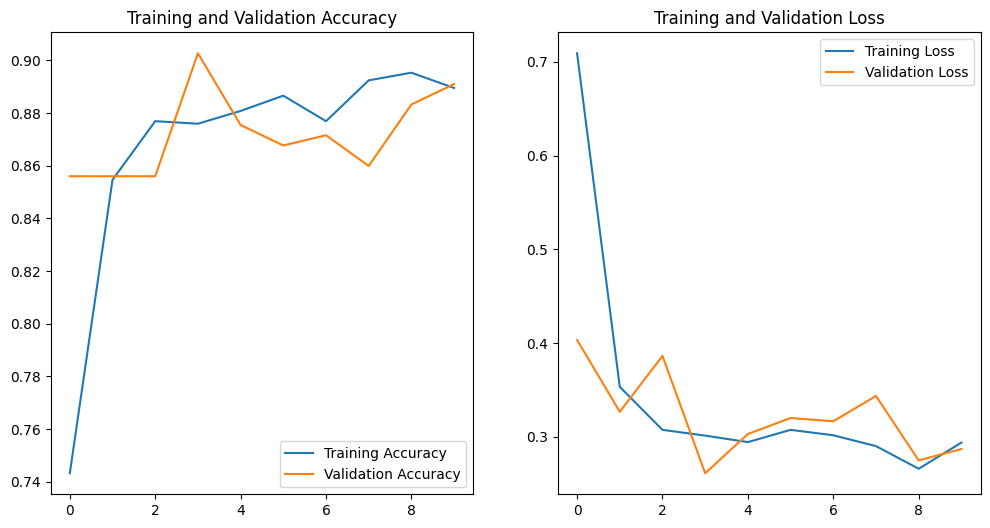

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()